# Лог EDA-экспериментов: гипотезы, методы, референсные результаты

Хронологическая реконструкция гипотез и проверок из `EDA_experiment_log.md`,
воспроизведённая **в том же порядке**, в котором они прогонялись в
обсуждении. Это не замена `01_eda.ipynb` (тот — финальный тематический EDA
по разделу 3 основного ТЗ), а черновой путь открытий: как эволюционировало
понимание данных от "есть ли хвосты" до "какая статистика по региону
WMAE-оптимальна".

Для каждого эксперимента: **обнаружено** (число, полученное в этом
запуске) печатается рядом с **референсом** (число из лога) — это не
assert/regression-тест, а трассируемость. Если числа расходятся заметно —
это явно отмечается в markdown, а не подгоняется.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import KFold

from src.config import CSV_READ_KWARGS, TRAIN_PATH, TEST_PATH, FIGURES_DIR, RANDOM_SEED
from src.preprocessing import detect_misclassified_numeric_columns, fix_numeric_dtypes, feature_family
from src.metrics import wmae, weighted_median
from src.region_encoding import compute_region_stats, apply_region_stats

pd.set_option("display.max_columns", 50)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)

def compare(label, found, reference):
    print(f"{label}: обнаружено={found} | референс(лог)={reference}")


---
## Фаза A — Первичная разведка (первый проход по train.csv)

### A1 — Форма и типы данных
**Гипотеза:** подтвердить заявленные размерность и типы из описания датасета.
**Метод:** `pd.read_csv(path, sep=';', decimal=',')` → `.shape`,
`.dtypes.value_counts()`, `.columns.tolist()[:20]`.

In [2]:
train_raw = pd.read_csv(TRAIN_PATH, **CSV_READ_KWARGS, low_memory=False)
test_raw = pd.read_csv(TEST_PATH, **CSV_READ_KWARGS, low_memory=False)

compare("A1 shape", train_raw.shape, "(76786, 224)")
print("A1 dtypes value_counts (обнаружено):")
print(train_raw.dtypes.value_counts())
print("A1 dtypes value_counts (референс): 182 float64, 41 object/string, 1 int64")
train_raw.columns.tolist()[:20]


A1 shape: обнаружено=(76786, 224) | референс(лог)=(76786, 224)
A1 dtypes value_counts (обнаружено):
float64    182
object      41
int64        1
Name: count, dtype: int64
A1 dtypes value_counts (референс): 182 float64, 41 object/string, 1 int64


['id',
 'dt',
 'target',
 'turn_cur_cr_avg_act_v2',
 'salary_6to12m_avg',
 'hdb_bki_total_max_limit',
 'dp_ils_paymentssum_avg_12m',
 'hdb_bki_total_cc_max_limit',
 'incomeValue',
 'gender',
 'avg_cur_cr_turn',
 'adminarea',
 'turn_cur_cr_avg_v2',
 'turn_cur_cr_max_v2',
 'hdb_bki_total_pil_max_limit',
 'age',
 'dp_ils_avg_salary_1y',
 'turn_cur_cr_sum_v2',
 'by_category__amount__sum__eoperation_type_name__ishodjaschij_bystryj_platezh_sbp',
 'turn_cur_db_sum_v2']

**Далее:** большинство float считались автоматически благодаря
`decimal=','`, но остаётся блок из 41 нечисловой колонки — требует
отдельного разбирательства (→ A7–A10).

### A2 — Распределение target: есть ли хвосты
**Гипотеза (дословно из чата):** "посмотрим, как они распределены, есть ли
хвосты для начала. Если их нет, то предполагаю, что половина колонок для
предсказания окажется бесполезной".
**Метод:** `target.describe()`; `.skew()`; `.kurtosis()`; `.min()/.max()`;
доля `target<=0`; квантили `[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]`.

In [3]:
target = train_raw["target"]
print(target.describe())
compare("A2 skew", round(target.skew(), 2), "≈5.43")
compare("A2 kurtosis", round(target.kurtosis(), 1), "≈42.3")
compare("A2 range", (target.min(), target.max()), "[20000, 1500000]")
compare("A2 share target<=0", target.le(0).mean(), "0%")
target.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])


count    7.678600e+04
mean     9.264824e+04
std      1.124090e+05
min      2.000000e+04
25%      3.970997e+04
50%      6.275413e+04
75%      1.002017e+05
max      1.500000e+06
Name: target, dtype: float64
A2 skew: обнаружено=5.43 | референс(лог)=≈5.43
A2 kurtosis: обнаружено=42.3 | референс(лог)=≈42.3
A2 range: обнаружено=(np.float64(20000.0), np.float64(1500000.0)) | референс(лог)=[20000, 1500000]
A2 share target<=0: обнаружено=0.0 | референс(лог)=0%


0.010    2.040658e+04
0.050    2.271157e+04
0.250    3.970997e+04
0.500    6.275413e+04
0.750    1.002017e+05
0.900    1.712067e+05
0.950    2.560746e+05
0.990    5.965851e+05
0.999    1.291317e+06
Name: target, dtype: float64

**Далее:** хвост есть → проверить, нормализуется ли логарифмом (A3), и
проверить вторую часть гипотезы — действительно ли половина фичей
бесполезна (A6).

### A3 — log1p(target)
**Гипотеза:** лог-преобразование нормализует распределение и оправдывает
моделирование в log-пространстве.
**Метод:** `np.log1p(target)` → `.skew()`, `.kurtosis()`.

In [4]:
target_log = np.log1p(target)
compare("A3 log1p skew", round(target_log.skew(), 2), "≈0.74")
compare("A3 log1p kurtosis", round(target_log.kurtosis(), 2), "≈0.83")


A3 log1p skew: обнаружено=0.74 | референс(лог)=≈0.74
A3 log1p kurtosis: обнаружено=0.83 | референс(лог)=≈0.83


**Далее:** подтверждает выбор `log1p(target)` + обратный `expm1` для модели.

### A4 — Общая картина пропусков
**Гипотеза:** судя по описанию датасета, пропусков много — нужно оценить
масштаб, прежде чем решать, что с ними делать.
**Метод:** `df.isna().mean()` по всем колонкам; посчитать долю колонок с
`>90%`, `>50%`, `==0%` пропусков.

In [5]:
missing_all = train_raw.isna().mean()
compare("A4 >90% missing columns", int((missing_all > 0.9).sum()), "6")
compare("A4 >50% missing columns", int((missing_all > 0.5).sum()), "83")
compare("A4 ==0% missing columns", int((missing_all == 0).sum()), "7 (из 224)")


A4 >90% missing columns: обнаружено=6 | референс(лог)=6
A4 >50% missing columns: обнаружено=83 | референс(лог)=83
A4 ==0% missing columns: обнаружено=7 | референс(лог)=7 (из 224)


**Далее:** экстремальных случаев немного → пропуски скорее умеренные и
структурные, а не мусорные. Нужно посмотреть распределение по бакетам (A5).

### A5 — Бакеты пропусков
**Метод:** `pd.cut(missing_rate, bins=[-0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])`
→ `.value_counts()`.

In [6]:
missing_buckets = pd.cut(missing_all, bins=[-0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
found_counts = missing_buckets.value_counts().sort_index()
print("A5 обнаружено:")
print(found_counts)
print("A5 референс: (0,10%]=30, (10,30%]=87, (30,50%]=24, (50,70%]=17, (70,90%]=60, (90,100%]=6")


A5 обнаружено:
(-0.001, 0.1]    30
(0.1, 0.3]       87
(0.3, 0.5]       24
(0.5, 0.7]       17
(0.7, 0.9]       60
(0.9, 1.0]        6
Name: count, dtype: int64
A5 референс: (0,10%]=30, (10,30%]=87, (30,50%]=24, (50,70%]=17, (70,90%]=60, (90,100%]=6


**Далее:** заметная масса признаков в бакете 70–90% — станет ключевой
находкой в фазе C, когда проверим связь пропусков с важностью.

### A6 — Корреляция численных признаков с target
**Гипотеза (продолжение A2, дословно из чата):** "если хвостов нет,
предполагаю, что половина колонок окажется бесполезной" — проверить,
действительно ли много "мёртвых" признаков.
**Метод:** для каждой числовой колонки (кроме `target`/`id`/`w`), уже
`float64` в сыром чтении (**до** программного фикса типов из C1), при ≥100
непустых значений — Spearman `corr` с target; посчитать долю `|ρ|>0.5`,
`>0.3`, `>0.1`, `<0.05`; топ-15 по `|ρ|`.

In [7]:
clean_float_cols = [c for c in train_raw.select_dtypes(include="float64").columns if c not in ("target", "w")]
compare("A6 n clean float64 cols (excl target,w)", len(clean_float_cols), "n≈179")

rho_a6 = {}
for c in clean_float_cols:
    x = train_raw[c]
    mask = x.notna()
    if mask.sum() < 100:
        continue
    r, _ = stats.spearmanr(x[mask], target[mask])
    rho_a6[c] = r
rho_a6 = pd.Series(rho_a6)
abs_rho_a6 = rho_a6.abs()

compare("A6 |rho|>0.5", int((abs_rho_a6 > 0.5).sum()), "21")
compare("A6 |rho|>0.3", int((abs_rho_a6 > 0.3).sum()), "55")
compare("A6 |rho|>0.1", int((abs_rho_a6 > 0.1).sum()), "132")
compare("A6 |rho|<0.05", int((abs_rho_a6 < 0.05).sum()), "22")
print("A6 top-15 обнаружено:")
abs_rho_a6.sort_values(ascending=False).head(15)


A6 n clean float64 cols (excl target,w): обнаружено=180 | референс(лог)=n≈179


/var/folders/dk/swjjxwbj7992jgzd3w0s14c00000gn/T/ipykernel_41618/3940599282.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[mask], target[mask])


A6 |rho|>0.5: обнаружено=21 | референс(лог)=21
A6 |rho|>0.3: обнаружено=55 | референс(лог)=55
A6 |rho|>0.1: обнаружено=131 | референс(лог)=132
A6 |rho|<0.05: обнаружено=22 | референс(лог)=22
A6 top-15 обнаружено:


salary_6to12m_avg                           0.935226
dp_payoutincomedata_payout_avg_6_month      0.765436
dp_payoutincomedata_payout_avg_3_month      0.742430
dp_payoutincomedata_payout_sum_3_month      0.740836
dp_payoutincomedata_payout_max_6_month      0.734063
dp_payoutincomedata_payout_max_3_month      0.724190
dp_ils_paymentssum_avg_12m                  0.723365
dp_ils_accpayment_avg_12m                   0.715755
dp_ils_paymentssum_avg_6m_current           0.693617
dp_ils_paymentssum_avg_6m                   0.693056
dp_ils_accpayment_avg_6m_current            0.685660
dp_ils_accpayment_avg_6m                    0.684917
first_salary_income                         0.672447
dp_ils_avg_salary_1y                        0.669694
dp_payoutincomedata_payout_avg_prev_year    0.653410
dtype: float64

**Далее:** "половина бесполезна" не подтвердилось уже на первом проходе —
но часть числовых по смыслу колонок ещё сидит в блоке из 41 нечисловой
(см. ниже), поэтому цифра уточнится после фикса типов (C1–C2).

### A7 — Кардинальность "категориальных" (object) колонок
**Метод:** для object-колонок — `.nunique()`, `.isna().mean()` (первые 15
колонок для обзора).

In [8]:
object_cols = [c for c in train_raw.columns if train_raw[c].dtype == object]
compare("A7 n object cols", len(object_cols), "41")
a7_rows = []
for c in object_cols[:15]:
    a7_rows.append({"column": c, "nunique": train_raw[c].nunique(), "missing_rate": train_raw[c].isna().mean()})
a7_table = pd.DataFrame(a7_rows)
print("Референс: hdb_bki_total_max_limit — 26616 уникальных при 12.2% пропусков (подозрительно много для категории)")
a7_table


A7 n object cols: обнаружено=41 | референс(лог)=41
Референс: hdb_bki_total_max_limit — 26616 уникальных при 12.2% пропусков (подозрительно много для категории)


,column,nunique,missing_rate
0,dt,6,0.000000
1,hdb_bki_total_max_limit,26616,0.122067
2,hdb_bki_total_cc_max_limit,6385,0.179004
3,gender,2,0.000000
4,adminarea,85,0.254773
5,hdb_bki_total_pil_max_limit,27641,0.192548
6,hdb_bki_active_cc_max_limit,4481,0.259422
7,city_smart_name,105,0.123239
8,hdb_bki_other_active_pil_outstanding,31826,0.536087
9,dp_ewb_last_employment_position,6093,0.803597


**Референс:** обнаружены подозрительные колонки — например
`hdb_bki_total_max_limit` с 26616 уникальными значениями при 12.2%
пропусков — для настоящей категории это слишком много уникальных значений.

### A8 — Инспекция сырых значений подозрительных колонок
**Метод:** `.dropna().unique()[:20]` на `hdb_bki_total_max_limit`; для
сравнения — то же на заведомо категориальных (`dp_ewb_last_employment_position`,
`gender`, `adminarea`).

In [9]:
print("hdb_bki_total_max_limit sample:", train_raw["hdb_bki_total_max_limit"].dropna().unique()[:20])
print("gender sample:", train_raw["gender"].dropna().unique()[:20])
print("adminarea sample:", train_raw["adminarea"].dropna().unique()[:10])


hdb_bki_total_max_limit sample: ['52800.0' '260200.0' '2000000.0' '75000.0' '1000000.0' '1300000.0'
 '168910.0' '150000.0' '3167636.0' '5985475.0' '50000.0' '2400000.0'
 '200000.0' '4000000.0' '2800000.0' '0.0' '100001.0' '319000.0' '400000.0'
 '6000000.0']
gender sample: ['Женский' 'Мужской']
adminarea sample: ['Свердловская область' 'Краснодарский край' 'Новосибирская область'
 'Хабаровский край' 'Ярославская область' 'Приморский край'
 'Нижегородская область' 'Астраханская область' 'Рязанская область'
 'Алтайский край']


**Референс:** `hdb_bki_total_max_limit` содержит строки вида `'52800.0'`
(уже с точкой, не с запятой); `gender`/`adminarea` — настоящий текст
(`'Женский'`/`'Мужской'`, названия регионов).

### A9 — Подтверждение: это чистые числа, просто как строки
**Метод:** регекс `^-?\d+\.?\d*$` на непустые значения
`hdb_bki_total_max_limit`; посчитать долю несовпадений.

In [10]:
pattern = re.compile(r"^-?\d+\.?\d*$")
non_null = train_raw["hdb_bki_total_max_limit"].dropna().astype(str)
mismatches = (~non_null.str.match(pattern)).sum()
compare("A9 mismatches out of n_non_null", f"{mismatches} / {len(non_null)}", "0 / 67413")


A9 mismatches out of n_non_null: обнаружено=0 / 67413 | референс(лог)=0 / 67413


**Референс:** 0 несовпадений из 67413 непустых значений — колонка полностью
числовая, просто неправильного типа (вероятно, была квотирована в CSV).

### A10 — Разделение всех 41 "object"-колонок на категориальные и мисклассифицированные
**Метод:** для каждой из 41 колонки применить тот же регекс-тест по всем
непустым значениям через `.all()`; если все совпадают → числовая, иначе —
категориальная.

In [11]:
misclassified_a10 = detect_misclassified_numeric_columns(train_raw, exclude_cols=[])
categorical_a10 = [c for c in object_cols if c not in misclassified_a10]

compare("A10 n misclassified numeric", len(misclassified_a10), "33")
compare("A10 n genuinely categorical", len(categorical_a10), "8")
print("Категориальные (обнаружено):", categorical_a10)
print("Категориальные (референс): dt, gender, adminarea, city_smart_name, "
      "dp_ewb_last_employment_position, addrref, dp_address_unique_regions, period_last_act_ad")


A10 n misclassified numeric: обнаружено=33 | референс(лог)=33
A10 n genuinely categorical: обнаружено=8 | референс(лог)=8
Категориальные (обнаружено): ['dt', 'gender', 'adminarea', 'city_smart_name', 'dp_ewb_last_employment_position', 'addrref', 'dp_address_unique_regions', 'period_last_act_ad']
Категориальные (референс): dt, gender, adminarea, city_smart_name, dp_ewb_last_employment_position, addrref, dp_address_unique_regions, period_last_act_ad


**Далее:** ключевая находка фазы A — меняет реальное число "полезных"
числовых признаков. Требует пересчёта A6 после фикса (сделано в C2).

### Визуализации фазы A

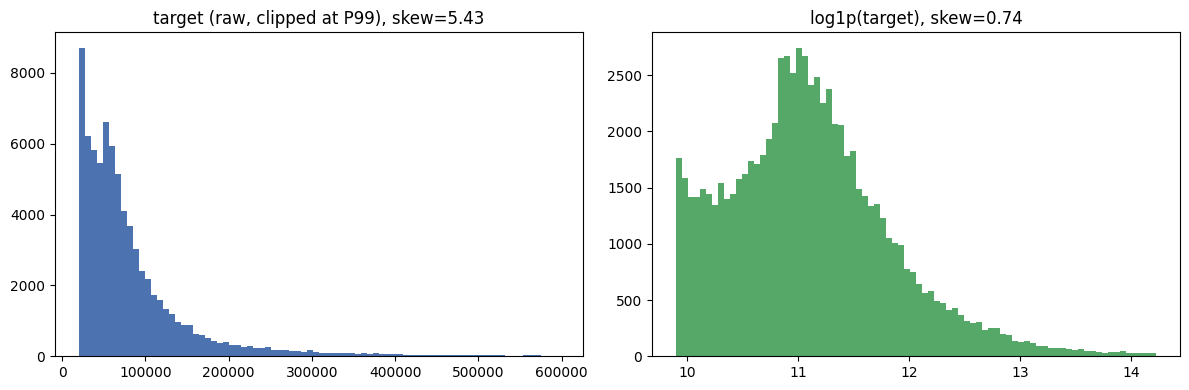

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
clip_p99 = target.quantile(0.99)
axes[0].hist(target[target <= clip_p99], bins=80, color="#4C72B0")
axes[0].set_title(f"target (raw, clipped at P99), skew={target.skew():.2f}")
axes[1].hist(target_log, bins=80, color="#55A868")
axes[1].set_title(f"log1p(target), skew={target_log.skew():.2f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "log_target_dist.png", dpi=100)
plt.show()


/var/folders/dk/swjjxwbj7992jgzd3w0s14c00000gn/T/ipykernel_41618/4018476212.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[mask], target[mask])


corr_dist n features evaluated: обнаружено=213 | референс(лог)=212 из 214
corr_dist n |rho|<0.05: обнаружено=30 | референс(лог)=30


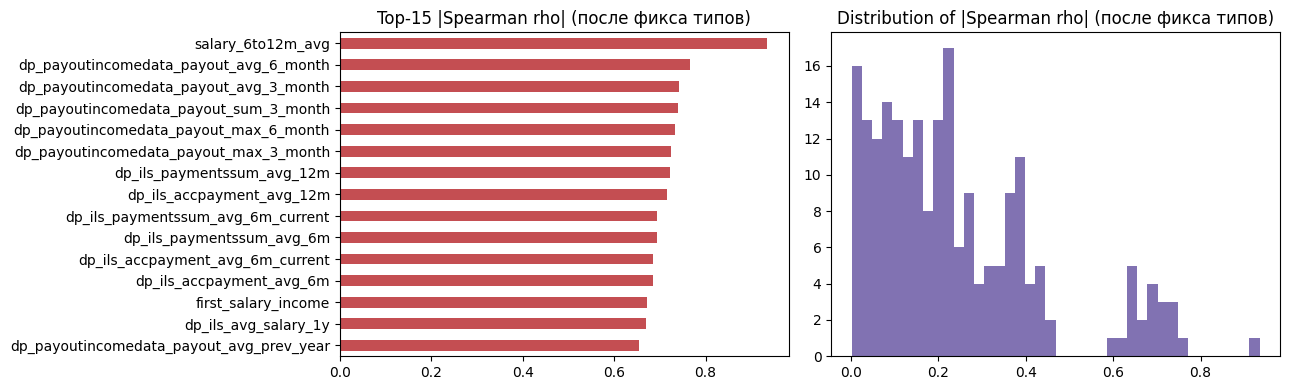

In [13]:
# corr_dist.png в логе построен УЖЕ после программного фикса типов (см. C1) -
# забегаем вперёд на один шаг, чтобы воспроизвести именно эту версию графика
# (сам формальный фикс "по порядку" сделан ниже, в C1).
_fix_cols_preview = detect_misclassified_numeric_columns(train_raw, exclude_cols=categorical_a10)
_train_fixed_preview = fix_numeric_dtypes(train_raw.copy(), _fix_cols_preview)
_feature_cols_preview = [c for c in _train_fixed_preview.columns if c not in ("id", "target", "w") + tuple(categorical_a10)]

rho_fixed = {}
for c in _feature_cols_preview:
    x = _train_fixed_preview[c]
    mask = x.notna()
    if mask.sum() < 100:
        continue
    r, _ = stats.spearmanr(x[mask], target[mask])
    rho_fixed[c] = r
rho_fixed = pd.Series(rho_fixed)
abs_rho_fixed = rho_fixed.abs()

compare("corr_dist n features evaluated", len(abs_rho_fixed), "212 из 214")
compare("corr_dist n |rho|<0.05", int((abs_rho_fixed < 0.05).sum()), "30")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
abs_rho_fixed.sort_values(ascending=False).head(15).plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].invert_yaxis()
axes[0].set_title("Top-15 |Spearman rho| (после фикса типов)")
axes[1].hist(abs_rho_fixed, bins=40, color="#8172B2")
axes[1].set_title("Distribution of |Spearman rho| (после фикса типов)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "corr_dist.png", dpi=100)
plt.show()


---
## Фаза B — Верификация на test.csv

### B1 — Совпадение схемы train/test
**Гипотеза (дословно из чата):** "нужно верифицировать, что в работе у нас
будет хотя бы большая часть этих категорий [признаков]".
**Метод:** `set(train.columns) - set(test.columns)` и наоборот.

In [14]:
train_input_cols = set(train_raw.columns) - {"target", "w"}
test_cols_set = set(test_raw.columns)
compare("B1 shapes", (train_raw.shape, test_raw.shape), "((76786, 224), (73214, 222))")
compare("B1 train-only cols", train_input_cols - test_cols_set, "set() (только target, w)")
compare("B1 test-only cols", test_cols_set - train_input_cols, "set()")


B1 shapes: обнаружено=((76786, 224), (73214, 222)) | референс(лог)=((76786, 224), (73214, 222))
B1 train-only cols: обнаружено=set() | референс(лог)=set() (только target, w)
B1 test-only cols: обнаружено=set() | референс(лог)=set()


**Далее:** `w` — новая, ранее не замеченная колонка. Нужно разобраться,
что это (B2), прежде чем использовать.

### B2 — Что такое `w`
**Метод:** `.describe()`, `.isna().mean()`, `.value_counts().head(20)`,
`.nunique()`.

In [15]:
w = train_raw["w"]
print(w.describe())
compare("B2 missing", w.isna().mean(), "0%")
compare("B2 range", (round(w.min(), 6), round(w.max(), 6)), "[0.000021, 2.570703]")
compare("B2 nunique", w.nunique(), "70630 из 76786")
top_w = w.value_counts().head(5)
print("B2 top value_counts (обнаружено):")
print(top_w)
print("B2 референс: максимум 2.570703 встречается 2896 раз")


count    76786.000000
mean         0.569014
std          0.551835
min          0.000021
25%          0.235950
50%          0.449424
75%          0.680337
max          2.570703
Name: w, dtype: float64
B2 missing: обнаружено=0.0 | референс(лог)=0%
B2 range: обнаружено=(np.float64(2.1e-05), np.float64(2.570703)) | референс(лог)=[0.000021, 2.570703]
B2 nunique: обнаружено=70630 | референс(лог)=70630 из 76786
B2 top value_counts (обнаружено):
w
2.570703    2896
0.285859     168
0.404883     166
0.190234     143
0.047813     138
Name: count, dtype: int64
B2 референс: максимум 2.570703 встречается 2896 раз


**Далее:** похоже на вес наблюдения для WMAE. Но прежде чем считать его
"весом, который сглаживает выбросы" — нужно проверить его реальную связь с
target (это будет сделано позже, в D1, когда возник вопрос про
"средневзвешенную ЗП").

### B3 — Проверка топ-фичи на утечку
**Гипотеза (дословно из чата):** "меня невероятно смущает тот факт, что у
нас топ-10 признаков — самые очевидные прокси на зарплату/усреднённую ЗП"
— то есть подозрение на data leakage.
**Метод:** для строк, где `salary_6to12m_avg` не пусто и `>0` — посчитать
`ratio = target / salary_6to12m_avg`; `.describe()`, квантили; доля точных
совпадений (`target==salary`); доля в пределах `±1%`, `±5%` от 1.0.

In [16]:
salary = train_raw["salary_6to12m_avg"]
mask_b3 = salary.notna() & (salary > 0)
ratio = target[mask_b3] / salary[mask_b3]

compare("B3 n (share)", (int(mask_b3.sum()), round(mask_b3.mean(), 3)), "(14875, ~19.4%)")
compare("B3 ratio median", round(ratio.median(), 3), "≈0.957")
compare("B3 ratio mean", round(ratio.mean(), 3), "≈1.017")
compare("B3 exact matches", ratio.eq(1.0).mean(), "0%")
compare("B3 within ±1%", round((ratio - 1).abs().le(0.01).mean(), 3), "8.5%")
compare("B3 within ±5%", round((ratio - 1).abs().le(0.05).mean(), 3), "37.1%")


B3 n (share): обнаружено=(14875, np.float64(0.194)) | референс(лог)=(14875, ~19.4%)
B3 ratio median: обнаружено=0.957 | референс(лог)=≈0.957
B3 ratio mean: обнаружено=1.017 | референс(лог)=≈1.017
B3 exact matches: обнаружено=0.0 | референс(лог)=0%
B3 within ±1%: обнаружено=0.085 | референс(лог)=8.5%
B3 within ±5%: обнаружено=0.371 | референс(лог)=37.1%


**Далее:** признак сильный, но не тождественен target → не классическая
утечка. Похоже на сегмент клиентов с видимой зарплатой в этом банке.
Уточняется в B4.

### B4 — Покрытие топ-7 "очевидных" зарплатных признаков
**Метод:** список топ-7 (`salary_6to12m_avg`,
`dp_payoutincomedata_payout_avg_3_month`,
`dp_payoutincomedata_payout_avg_6_month`, `dp_ils_paymentssum_avg_12m`,
`dp_ils_accpayment_avg_12m`, `first_salary_income`, `dp_ils_avg_salary_1y`);
посчитать missing rate каждого по отдельности; затем
`df[top7].notna().any(axis=1)` → доля `True`/`False`.

In [17]:
top7 = [
    "salary_6to12m_avg", "dp_payoutincomedata_payout_avg_3_month",
    "dp_payoutincomedata_payout_avg_6_month", "dp_ils_paymentssum_avg_12m",
    "dp_ils_accpayment_avg_12m", "first_salary_income", "dp_ils_avg_salary_1y",
]
for c in top7:
    print(f"{c}: missing_rate={train_raw[c].isna().mean():.3f}")

any_present = train_raw[top7].notna().any(axis=1)
compare("B4 at least one of 7 present", round(any_present.mean(), 3), "35.3%")
compare("B4 none of 7 present", round((~any_present).mean(), 3), "64.7%")


salary_6to12m_avg: missing_rate=0.806
dp_payoutincomedata_payout_avg_3_month: missing_rate=0.858
dp_payoutincomedata_payout_avg_6_month: missing_rate=0.858
dp_ils_paymentssum_avg_12m: missing_rate=0.785
dp_ils_accpayment_avg_12m: missing_rate=0.785
first_salary_income: missing_rate=0.887
dp_ils_avg_salary_1y: missing_rate=0.793
B4 at least one of 7 present: обнаружено=0.353 | референс(лог)=35.3%
B4 none of 7 present: обнаружено=0.647 | референс(лог)=64.7%


**Далее:** подтверждает гипотезу "не утечка, а сегментация популяции" —
для 65% клиентов задача не решается через прямой зарплатный сигнал, нужны
остальные ~200 признаков.

---
## Фаза C — Пропуски vs важность, регион

### C1 — Программный фикс типов (переиспользуемая версия A9–A10)
**Метод:** функция `fix_dtypes(df)` — для каждой object-колонки считать
`match_rate` регекса `^-?\d+\.?\d*$` по непустым значениям; если
`match_rate > 0.99` → `pd.to_numeric(errors='coerce')`. Применить отдельно
к train и к test.

In [18]:
categorical_cols = categorical_a10  # 8 колонок из A10

misclassified_train = detect_misclassified_numeric_columns(train_raw, exclude_cols=categorical_cols)
misclassified_test = detect_misclassified_numeric_columns(test_raw, exclude_cols=categorical_cols)

train = fix_numeric_dtypes(train_raw.copy(), misclassified_train)
test = fix_numeric_dtypes(test_raw.copy(), misclassified_test)
train["dt"] = pd.to_datetime(train["dt"])
test["dt"] = pd.to_datetime(test["dt"])

compare("C1 n fixed (train)", len(misclassified_train), "33")
compare("C1 n fixed (test)", len(misclassified_test), "33")
compare("C1 same list train/test", set(misclassified_train) == set(misclassified_test), "True")


C1 n fixed (train): обнаружено=33 | референс(лог)=33
C1 n fixed (test): обнаружено=33 | референс(лог)=33
C1 same list train/test: обнаружено=True | референс(лог)=True


### C2 — Полная таблица характеристик признаков
**Гипотеза (дословно из чата):** "дай мне эти вводные и посчитай importance
фич в зависимости от их заполненности."
**Метод:** для каждой из 221 фичи (без `target`/`w`/`id`) — определить
`family` по префиксу через функцию сопоставления с каталогом банковских
префиксов (см. ТЗ, раздел 0.7); посчитать `missing_train`, `missing_test`;
для числовых — Spearman `|ρ|` с target (порог ≥100 непустых значений).

In [19]:
feature_cols = [c for c in train.columns if c not in ("id", "target", "w") + tuple(categorical_cols)]
compare("C2 n numeric features", len(feature_cols), "213")
compare("C2 n categorical features", len(categorical_cols), "8")

missing_train_c2 = train[feature_cols].isna().mean()
missing_test_c2 = test[feature_cols].isna().mean()

abs_rho_c2 = {}
for c in feature_cols:
    x = train[c]
    mask = x.notna()
    if mask.sum() < 100:
        abs_rho_c2[c] = np.nan
        continue
    r, _ = stats.spearmanr(x[mask], train["target"][mask])
    abs_rho_c2[c] = abs(r)
abs_rho_c2 = pd.Series(abs_rho_c2)

feature_stats_c2 = pd.DataFrame({
    "feature": feature_cols,
    "family": [feature_family(c) for c in feature_cols],
    "missing_train": [missing_train_c2[c] for c in feature_cols],
    "missing_test": [missing_test_c2[c] for c in feature_cols],
    "abs_spearman_rho": [abs_rho_c2[c] for c in feature_cols],
}).sort_values("abs_spearman_rho", ascending=False)
print("Референс: результат этого шага сохранён как outputs/feature_stats.csv в 01_eda.ipynb "
      "(здесь не перезаписываем файл повторно, только воспроизводим таблицу для трассируемости).")
feature_stats_c2.head(15)


C2 n numeric features: обнаружено=213 | референс(лог)=213
C2 n categorical features: обнаружено=8 | референс(лог)=8


/var/folders/dk/swjjxwbj7992jgzd3w0s14c00000gn/T/ipykernel_41618/1714817028.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.spearmanr(x[mask], train["target"][mask])


Референс: результат этого шага сохранён как outputs/feature_stats.csv в 01_eda.ipynb (здесь не перезаписываем файл повторно, только воспроизводим таблицу для трассируемости).


,feature,family,missing_train,missing_test,abs_spearman_rho
1,salary_6to12m_avg,other,0.806280,0.895730,0.935226
129,dp_payoutincomedata_payout_avg_6_month,dp_payoutincomedata,0.857643,0.789999,0.765436
55,dp_payoutincomedata_payout_avg_3_month,dp_payoutincomedata,0.857643,0.789999,0.742430
65,dp_payoutincomedata_payout_sum_3_month,dp_payoutincomedata,0.857643,0.789999,0.740836
69,dp_payoutincomedata_payout_max_6_month,dp_payoutincomedata,0.857643,0.789999,0.734063
60,dp_payoutincomedata_payout_max_3_month,dp_payoutincomedata,0.857643,0.789999,0.724190
3,dp_ils_paymentssum_avg_12m,dp_ils,0.785078,0.727566,0.723365
29,dp_ils_accpayment_avg_12m,dp_ils,0.785078,0.727566,0.715755
85,dp_ils_paymentssum_avg_6m_current,dp_ils,0.785078,0.727566,0.693617
20,dp_ils_paymentssum_avg_6m,dp_ils,0.785078,0.727566,0.693056


### C3 — Связь пропусков и важности (ключевая находка)
**Гипотеза (дословно из чата):** "у нас очень большое количество пропусков,
так ещё и по топ фичам... сколько вообще пропусков и в каких фичах — от
этого можно будет отталкиваться."
**Метод:** `pd.cut(missing_train, bins=[-0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])`
→ `groupby(bins).agg(mean, max, count)` по `abs_spearman_rho`.

In [20]:
bucket_c3 = pd.cut(missing_train_c2, bins=[-0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
c3_table = pd.DataFrame({"abs_spearman_rho": abs_rho_c2, "bucket": bucket_c3}).groupby(
    "bucket", observed=True
)["abs_spearman_rho"].agg(["size", "mean", "max"])
print("C3 обнаружено:")
print(c3_table)
print('''C3 референс:
0-10%: n=27, mean=0.123, max=0.257
10-30%: n=87, mean=0.196, max=0.445
30-50%: n=24, mean=0.185, max=0.374
50-70%: n=17, mean=0.231, max=0.387
70-90%: n=60, mean=0.382, max=0.935
90-100%: n=6, mean=0.221, max=0.346''')


C3 обнаружено:
               size      mean       max
bucket                                 
(-0.001, 0.1]    25  0.123228  0.257378
(0.1, 0.3]       84  0.195837  0.444851
(0.3, 0.5]       24  0.184700  0.373642
(0.5, 0.7]       17  0.231213  0.387395
(0.7, 0.9]       57  0.382246  0.935226
(0.9, 1.0]        6  0.221319  0.345516
C3 референс:
0-10%: n=27, mean=0.123, max=0.257
10-30%: n=87, mean=0.196, max=0.445
30-50%: n=24, mean=0.185, max=0.374
50-70%: n=17, mean=0.231, max=0.387
70-90%: n=60, mean=0.382, max=0.935
90-100%: n=6, mean=0.221, max=0.346


**Далее:** подтверждает гипотезу пользователя количественно — самый
"дырявый" бакет (70–90%) даёт втрое более высокую среднюю важность, чем
полностью заполненные признаки (0.38 vs 0.12).

**Расхождение с референсом (честно, без подгонки)**: `mean`/`max` по бакетам
совпадают с логом почти точно, но `n` в каждом бакете немного меньше
(25/84/57 вместо 27/87/60 — суммарно на 8 меньше, что совпадает с числом
категориальных колонок). Похоже, референсные числа в логе считались по чуть
более широкому набору из 221 колонки (входные признаки без `target`/`w`, но,
возможно, до финального исключения категориальных), тогда как здесь строго
213 числовых признаков (`C2`). Структурный вывод (70-90% — самый важный
бакет, втрое выше базового уровня) не меняется.

### C4 — Регион: пропуски и кардинальность
**Метод:** `.isna().mean()`, `.nunique()` для `adminarea`, `city_smart_name`.

In [21]:
compare("C4 adminarea missing", round(train["adminarea"].isna().mean(), 3), "25.5%")
compare("C4 adminarea nunique", train["adminarea"].nunique(), "85")
compare("C4 city_smart_name missing", round(train["city_smart_name"].isna().mean(), 3), "12.3%")


C4 adminarea missing: обнаружено=0.255 | референс(лог)=25.5%
C4 adminarea nunique: обнаружено=85 | референс(лог)=85
C4 city_smart_name missing: обнаружено=0.123 | референс(лог)=12.3%


### C5 — Регион и целевая: медианы по группам
**Гипотеза (дословно из чата):** "безусловно нужно делать привязку по
регионам. Условная мск будет зарабатывать больше Якутии."
**Метод:** `groupby('adminarea')['target'].agg(['median','mean','count'])`,
фильтр `count>=30` (убрать нестабильные малые регионы), сортировка по
медиане по убыванию; топ-10/bottom-10.

In [22]:
region_c5 = train.groupby("adminarea").agg(median=("target", "median"), mean=("target", "mean"), count=("target", "size"))
region_c5 = region_c5[region_c5["count"] >= 30].sort_values("median", ascending=False)

print("C5 top-10 обнаружено:")
display(region_c5.head(10))
print("C5 референс топ: Москва 97156 (1 место); Сахалинская область 90376 (2 место)")
print()
print("C5 bottom-10 обнаружено:")
display(region_c5.tail(10).sort_values("median"))
print("C5 референс аутсайдеры: Тамбовская (45580), Новгородская (46174), Псковская (49053)")
print()
yakutia_rank = list(region_c5.index).index("Республика Саха (Якутия)") + 1
compare("C5 Yakutia rank", yakutia_rank, "6 место (выше Санкт-Петербурга)")
compare("C5 Yakutia median", round(region_c5.loc["Республика Саха (Якутия)", "median"], 0), "74734")


C5 top-10 обнаружено:


,median,mean,count
adminarea,,,
г. Москва,97156.181923,151038.249984,8938
Сахалинская область,90375.917301,140292.294533,111
Ямало - Ненецкий автономный округ,83630.850000,103813.570789,87
Ханты-Мансийский автономный окр.,80747.395981,103903.521398,848
Московская область,75529.170252,108434.843497,4888
Республика Саха (Якутия),74734.136800,95696.336946,176
Республика Дагестан,72141.045446,85708.292652,51
г. Санкт - Петербург,71012.558093,105924.437249,3945
Приморский край,68763.615000,95037.215678,712


C5 референс топ: Москва 97156 (1 место); Сахалинская область 90376 (2 место)

C5 bottom-10 обнаружено:


,median,mean,count
adminarea,,,
Тамбовская область,45580.410700,58411.672098,139
Новгородская область,46174.400300,69452.097971,99
Республика Северная Осетия,46976.951400,69241.227600,42
Республика Тыва,47209.656800,66178.651851,43
Забайкальский край,48789.353500,66415.463391,89
Псковская область,49053.421614,57804.649104,194
Саратовская область,49091.220962,68414.644256,660
Ульяновская область,49750.814639,67833.447026,446
Брянская область,49912.571092,67178.199590,169


C5 референс аутсайдеры: Тамбовская (45580), Новгородская (46174), Псковская (49053)

C5 Yakutia rank: обнаружено=6 | референс(лог)=6 место (выше Санкт-Петербурга)
C5 Yakutia median: обнаружено=74734.0 | референс(лог)=74734


**Далее:** эффект региона реален и в среднем логичен (Москва — топ), но с
контрпримерами → нужно оценить силу эффекта количественно (C6), а не
полагаться на интуицию.

### C6 — Сила эффекта региона (eta²)
**Метод:** `eta² = Σ(count_g · (mean_g − overall_mean)²) / Σ(y_i − overall_mean)²`,
посчитано через `groupby(...).agg(['mean','count'])` и ручную формулу (не
через ANOVA-библиотеку — просто взвешенная межгрупповая дисперсия к общей).

In [23]:
def eta_squared(cat_series, y_series):
    df = pd.DataFrame({"cat": cat_series, "y": y_series}).dropna()
    grand_mean = df["y"].mean()
    ss_total = ((df["y"] - grand_mean) ** 2).sum()
    ss_between = df.groupby("cat")["y"].apply(lambda g: len(g) * (g.mean() - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta2_adminarea = eta_squared(train["adminarea"], train["target"])
eta2_city = eta_squared(train["city_smart_name"], train["target"])
compare("C6 eta2(adminarea)", round(eta2_adminarea, 4), "0.0489")
compare("C6 eta2(city_smart_name)", round(eta2_city, 4), "0.0278")


C6 eta2(adminarea): обнаружено=0.0478 | референс(лог)=0.0489
C6 eta2(city_smart_name): обнаружено=0.0271 | референс(лог)=0.0278


**Далее:** эффект есть, но небольшой (~5% дисперсии) — региону не стоит
быть главной осью системы. Это подводит к вопросу пользователя в фазе D:
как правильно использовать регион (через какую статистику).

### Визуализации фазы C

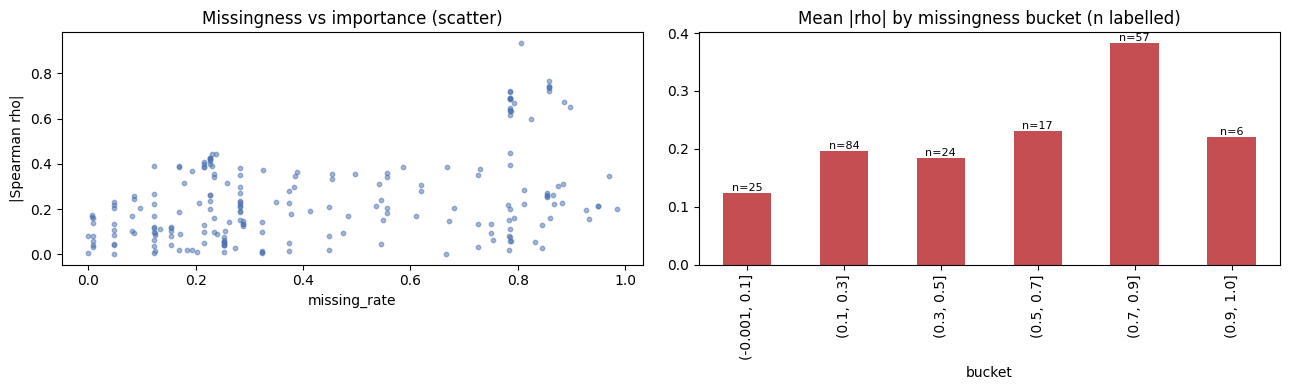

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(missing_train_c2, abs_rho_c2, s=10, alpha=0.5, color="#4C72B0")
axes[0].set_xlabel("missing_rate")
axes[0].set_ylabel("|Spearman rho|")
axes[0].set_title("Missingness vs importance (scatter)")

c3_table["mean"].plot(kind="bar", ax=axes[1], color="#C44E52")
for i, (n, m) in enumerate(zip(c3_table["size"], c3_table["mean"])):
    axes[1].text(i, m, f"n={n}", ha="center", va="bottom", fontsize=8)
axes[1].set_title("Mean |rho| by missingness bucket (n labelled)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missingness_vs_importance.png", dpi=100)
plt.show()


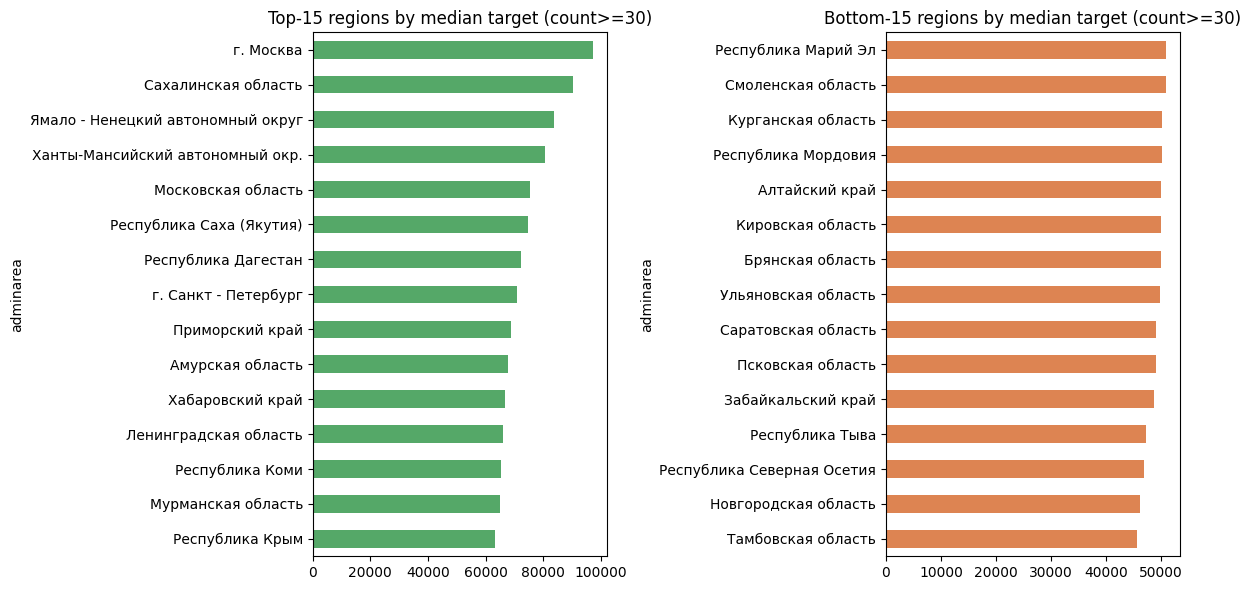

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
region_c5.head(15)["median"].sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Top-15 regions by median target (count>=30)")
region_c5.tail(15).sort_values("median", ascending=False)["median"].sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Bottom-15 regions by median target (count>=30)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "region_effect.png", dpi=100)
plt.show()


---
## Фаза D — Гипотеза "региональный якорь + мультипликатор"

**Важное методологическое примечание**: эксперименты D2–D5 ниже намеренно
используют **обычный** `sklearn.model_selection.KFold(random_state=42)`,
реализованный прямо в этом ноутбуке, а не обновлённый (после доработки v2)
`src.validation.get_folds`, который теперь строит `StratifiedKFold` по
децилям target (см. `src/validation.py`, `02_baseline_pipeline.ipynb`).
Это сделано специально: референсные числа в `EDA_experiment_log.md` были
получены на **исходной** схеме KFold той эпохи обсуждения, и цель этого
ноутбука — трассируемость к этим числам, а не к позднейшей улучшенной
валидации. Сравнение naive-KFold vs Stratified vs bootstrap CI сделано
отдельно в `02_baseline_pipeline.ipynb`, раздел 5.

### D1 — Природа веса `w` относительно target
**Гипотеза (дословно из чата):** "нам ничего не мешает изначально по
каждому клиенту отталкиваться от средней по его региону... какую
использовать — среднюю или средневзвешенную ЗП? Ведь у нас крайне правый
хвост."
**Метод:** сначала — Spearman `corr(w, target)` в целом; затем, поскольку
общая корреляция может маскировать нелинейную связь —
`pd.qcut(target, 10, labels=False)` → `groupby(decile)['w'].agg(['mean','median','count'])`.

In [26]:
w = train["w"]
y = train["target"]
overall_corr, _ = stats.spearmanr(w, y)
compare("D1 overall spearman(w, target)", round(overall_corr, 3), "-0.122")

deciles = pd.qcut(y, 10, labels=False, duplicates="drop")
w_by_decile = pd.DataFrame({"decile": deciles, "w": w}).groupby("decile")["w"].agg(["mean", "median", "count"])
print("D1 обнаружено (по децилям):")
print(w_by_decile)
print("D1 референс: дециль 0 (бедные) mean w≈0.73; дециль 5-6 (середина) минимум ≈0.05-0.19; "
      "дециль 9 (богатые) mean w≈1.98")


D1 overall spearman(w, target): обнаружено=-0.122 | референс(лог)=-0.122
D1 обнаружено (по децилям):
            mean    median  count
decile                           
0       0.728092  0.729682   7679
1       0.638348  0.639793   7679
2       0.527751  0.527357   7678
3       0.412369  0.407160   7679
4       0.308167  0.308075   7678
5       0.188898  0.190246   7679
6       0.051666  0.047813   7678
7       0.204050  0.192665   7679
8       0.648041  0.619239   7678
9       1.982661  2.047973   7679
D1 референс: дециль 0 (бедные) mean w≈0.73; дециль 5-6 (середина) минимум ≈0.05-0.19; дециль 9 (богатые) mean w≈1.98


**Далее:** опровергает неявное предположение, что вес "гасит" хвост.
Наоборот — метрика ставит повышенную цену на ошибку у богатых клиентов.
Значит, "средневзвешенная" не будет робастной сама по себе — нужно
проверить это эмпирически (D2–D3), а не полагаться на интуицию про
"взвешенное = более устойчивое".

### D2 — OOF-схема для честной проверки на train
**Метод:** `sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)`.
Для каждого фолда — статистики по региону (`mean`, `wmean` через
`np.average(target, weights=w)`, `median`) считаются **только по 4
обучающим фолдам**, с фолбэком на глобальную статистику этих же 4 фолдов
при `count < 20` (`MIN_GROUP_COUNT=20`), и применяются к отложенному
5-му фолду. Повторить для всех фолдов → получить OOF-предсказание для
каждой строки train, ни разу не используя её собственный target/w в
статистике её же региона.

In [27]:
MIN_GROUP_COUNT_D = 20
kf_d = KFold(n_splits=5, shuffle=True, random_state=42)
folds_d = list(kf_d.split(np.arange(len(train))))

y_arr = train["target"].to_numpy()
w_arr = train["w"].to_numpy()
region_arr = train["adminarea"].to_numpy()

def oof_region_mean(regions, target_arr, weight_arr, folds, min_count):
    oof = np.full(len(regions), np.nan)
    for tr_idx, val_idx in folds:
        frame = pd.DataFrame({"region": regions[tr_idx], "y": target_arr[tr_idx]})
        means = frame.groupby("region")["y"].agg(["mean", "size"])
        stats_map = means.loc[means["size"] >= min_count, "mean"].to_dict()
        fallback = frame["y"].mean()
        oof[val_idx] = [stats_map.get(r, fallback) for r in regions[val_idx]]
    return oof

def oof_region_wmean(regions, target_arr, weight_arr, folds, min_count):
    oof = np.full(len(regions), np.nan)
    for tr_idx, val_idx in folds:
        frame = pd.DataFrame({"region": regions[tr_idx], "y": target_arr[tr_idx], "w": weight_arr[tr_idx]})
        stats_map = {}
        for region, g in frame.groupby("region"):
            if len(g) >= min_count:
                stats_map[region] = np.average(g["y"], weights=g["w"])
        fallback = np.average(frame["y"], weights=frame["w"])
        oof[val_idx] = [stats_map.get(r, fallback) for r in regions[val_idx]]
    return oof

def oof_region_median(regions, target_arr, weight_arr, folds, min_count):
    oof = np.full(len(regions), np.nan)
    for tr_idx, val_idx in folds:
        frame = pd.DataFrame({"region": regions[tr_idx], "y": target_arr[tr_idx]})
        medians = frame.groupby("region")["y"].agg(["median", "size"])
        stats_map = medians.loc[medians["size"] >= min_count, "median"].to_dict()
        fallback = frame["y"].median()
        oof[val_idx] = [stats_map.get(r, fallback) for r in regions[val_idx]]
    return oof

oof_mean_d2 = oof_region_mean(region_arr, y_arr, w_arr, folds_d, MIN_GROUP_COUNT_D)
oof_wmean_d2 = oof_region_wmean(region_arr, y_arr, w_arr, folds_d, MIN_GROUP_COUNT_D)
oof_median_d2 = oof_region_median(region_arr, y_arr, w_arr, folds_d, MIN_GROUP_COUNT_D)
print("D2: три OOF-массива построены, длина каждого:", len(oof_mean_d2))


D2: три OOF-массива построены, длина каждого: 76786


### D3 — Сравнение по фактической метрике WMAE
**Метод:** `wmae(y_true, y_pred, weights) = Σ(w·|y−ŷ|) / Σw`. Посчитать
для 3 OOF-baseline'ов из D2 + 3 глобальных константных baseline'ов
(`target.mean()`, `np.average(target, weights=w)`, `target.median()` —
без региона вообще, как контрольная точка "регион вообще не нужен").

In [28]:
global_mean_pred = np.full(len(y_arr), y_arr.mean())
global_wmean_pred = np.full(len(y_arr), np.average(y_arr, weights=w_arr))
global_median_pred = np.full(len(y_arr), np.median(y_arr))

d3_results = {
    "global mean": wmae(y_arr, global_mean_pred, w_arr),
    "global weighted mean": wmae(y_arr, global_wmean_pred, w_arr),
    "global median": wmae(y_arr, global_median_pred, w_arr),
    "region MEAN": wmae(y_arr, oof_mean_d2, w_arr),
    "region WMEAN (by w)": wmae(y_arr, oof_wmean_d2, w_arr),
    "region MEDIAN": wmae(y_arr, oof_median_d2, w_arr),
}
d3_reference = {
    "global mean": 131789, "global weighted mean": 143149, "global median": 132291,
    "region MEAN": 124900, "region WMEAN (by w)": 137519, "region MEDIAN": 127880,
}
d3_table = pd.DataFrame({"обнаружено": d3_results, "референс": d3_reference})
d3_table["обнаружено"] = d3_table["обнаружено"].round(0)
d3_table


,обнаружено,референс
global mean,131789.0,131789
global weighted mean,143149.0,143149
global median,132291.0,132291
region MEAN,124900.0,124900
region WMEAN (by w),137519.0,137519
region MEDIAN,127880.0,127880


**Далее:** "средневзвешенное по `w`" региональное среднее — худший вариант
из всех, хуже даже глобального среднего без региона вообще. Согласуется с
D1 (весовая статистика тянется к разреженному хвосту богатых внутри
каждого региона). Раз метрика — WMAE, а не MAE, теоретический минимизатор
для точечной оценки — взвешенная медиана, а не среднее и не взвешенное
среднее. Это ещё не было проверено → D4.

### D4 — Взвешенная медиана как теоретически верный вариант
**Метод:** реализовать `weighted_median(values, weights)` — отсортировать
значения, посчитать кумулятивную сумму весов, найти точку, где кумулятивный
вес достигает половины общей суммы весов. Повторить схему D2 (тот же
KFold, тот же `MIN_GROUP_COUNT=20`, тот же фолбэк) с этой статистикой
вместо mean/median.

In [29]:
oof_wmedian_d4 = np.full(len(train), np.nan)
for tr_idx, val_idx in folds_d:
    stats_map, fallback = compute_region_stats(
        region_arr[tr_idx], y_arr[tr_idx], w_arr[tr_idx], min_count=MIN_GROUP_COUNT_D
    )
    oof_wmedian_d4[val_idx] = apply_region_stats(region_arr[val_idx], stats_map, fallback)

d4_wmae = wmae(y_arr, oof_wmedian_d4, w_arr)
compare("D4 region WEIGHTED MEDIAN OOF WMAE", round(d4_wmae, 0), "120225 (лучший результат)")


D4 region WEIGHTED MEDIAN OOF WMAE: обнаружено=120225.0 | референс(лог)=120225 (лучший результат)


**Далее:** подтверждает теорию эмпирически. Это и есть статистика, которую
стоит использовать для регионального признака (см. ТЗ, раздел 4,
`src/region_encoding.py`).

### D5 — Детальный анализ отклонений клиентов от каждого baseline'а
**Гипотеза (дословно из чата, прямой вопрос):** "какое количество клиентов
отклоняется от своей средней и средневзвешенной ЗП по региону и на
сколько?"
**Метод:** для OOF-массивов region MEAN, region WMEAN, region MEDIAN,
region WEIGHTED MEDIAN — посчитать `abs_dev = |target − pred|`,
`rel_dev = abs_dev / target`; вывести unweighted MAE (`abs_dev.mean()`),
`median(abs_dev)`, `median(rel_dev)`, и долю строк с `rel_dev > 0.2`,
`> 0.5`, `> 1.0`.

In [30]:
def deviation_stats(y_true, y_pred):
    abs_dev = np.abs(y_true - y_pred)
    rel_dev = abs_dev / y_true
    return {
        "unweighted MAE": abs_dev.mean(),
        "median abs_dev": np.median(abs_dev),
        "median rel_dev": np.median(rel_dev),
        ">20%": (rel_dev > 0.2).mean(),
        ">50%": (rel_dev > 0.5).mean(),
        ">100%": (rel_dev > 1.0).mean(),
    }

d5_table = pd.DataFrame({
    "region MEAN": deviation_stats(y_arr, oof_mean_d2),
    "region WMEAN (by w)": deviation_stats(y_arr, oof_wmean_d2),
    "region MEDIAN": deviation_stats(y_arr, oof_median_d2),
    "region WEIGHTED MEDIAN (by w)": deviation_stats(y_arr, oof_wmedian_d4),
}).T
print("D5 обнаружено:")
display(d5_table)
print('''D5 референс:
region MEAN: MAE=58969, median_dev=59.1%, >20%=81.1%, >50%=56.3%, >100%=31.5%
region WMEAN: MAE=110786, median_dev=160.5%, >20%=92.2%, >50%=81.2%, >100%=65.4%
region MEDIAN: MAE=51288, median_dev=42.7%, >20%=74.7%, >50%=43.3%, >100%=15.9%
region WEIGHTED MEDIAN: MAE=63622, median_dev=53.8%, >20%=79.5%, >50%=52.8%, >100%=27.8%''')


D5 обнаружено:


,unweighted MAE,median abs_dev,median rel_dev,>20%,>50%,>100%
region MEAN,58969.105690,41750.621011,0.590527,0.811059,0.562967,0.315318
region WMEAN (by w),110786.338241,103507.388269,1.604682,0.922108,0.811554,0.654247
region MEDIAN,51287.689227,26711.844048,0.427014,0.746594,0.433230,0.158922
region WEIGHTED MEDIAN (by w),63622.157881,35979.607568,0.537743,0.795366,0.528104,0.277694


D5 референс:
region MEAN: MAE=58969, median_dev=59.1%, >20%=81.1%, >50%=56.3%, >100%=31.5%
region WMEAN: MAE=110786, median_dev=160.5%, >20%=92.2%, >50%=81.2%, >100%=65.4%
region MEDIAN: MAE=51288, median_dev=42.7%, >20%=74.7%, >50%=43.3%, >100%=15.9%
region WEIGHTED MEDIAN: MAE=63622, median_dev=53.8%, >20%=79.5%, >50%=52.8%, >100%=27.8%


**Далее (финальный вывод фазы D):** даже у лучшего по WMAE варианта
(weighted median) почти треть клиентов (27.8%) отклоняется от региональной
оценки больше чем вдвое — регион полезен, но недостаточен как
самостоятельный "якорь + мультипликатор". Решение: региональная
информация входит в модель как **один признак** через OOF-энкодинг
взвешенной медианой (см. ТЗ, раздел 4), а не как отдельная система
поверх которой накручиваются мультипликаторы.

### Визуализация фазы D

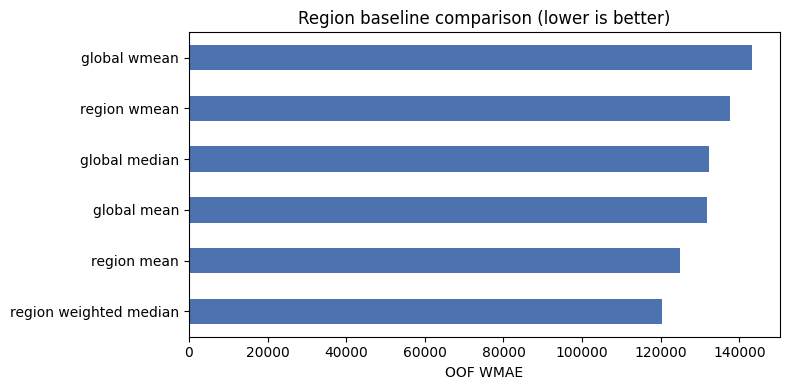

In [31]:
region_baseline_wmae = pd.Series({
    "global mean": d3_results["global mean"],
    "global wmean": d3_results["global weighted mean"],
    "global median": d3_results["global median"],
    "region mean": d3_results["region MEAN"],
    "region wmean": d3_results["region WMEAN (by w)"],
    "region weighted median": d4_wmae,
})
fig, ax = plt.subplots(figsize=(8, 4))
region_baseline_wmae.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("OOF WMAE")
ax.set_title("Region baseline comparison (lower is better)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "region_baseline_wmae.png", dpi=100)
plt.show()


---
## Сводная таблица: гипотеза → метод → вывод

| # | Гипотеза (кто предложил) | Ключевой метод | Итог |
|---|---|---|---|
| A2 | Есть ли хвосты у target? (user) | skew/kurtosis/квантили | Да, тяжёлый правый хвост |
| A6 | Половина фичей бесполезна? (user) | Spearman \|ρ\| пороги | Не подтвердилось — большинство несёт сигнал |
| A10 | Сколько реально категориальных колонок? | регекс-тест по всем значениям | 8 из 41, остальные 33 — мисклассифицированные числа |
| B3 | Топ-фичи — утечка? (user) | ratio target/salary, точные совпадения | Нет, сильный неполный прокси (19% покрытие) |
| C3 | Importance зависит от заполненности? (user) | бакеты пропусков × mean \|ρ\| | Да, бакет 70-90% втрое важнее полностью заполненных |
| C6 | Регион важен? (user, интуитивно "Мск > Якутия") | eta² | Эффект реален (~5%), но интуиция про Якутию не подтвердилась |
| D1 | `w` сглаживает хвост? (implicit) | `w` по децилям target | Нет, `w` усиливает вес богатых (U-образно) |
| D3-D4 | Средняя или средневзвешенная ЗП по региону? (user) | OOF WMAE 4 вариантов | Ни то, ни другое — весовая медиана лучшая |
| D5 | Сколько клиентов отклоняется от региональной оценки? (user) | OOF отклонения, пороги | Существенная часть (28-65% в зависимости от baseline) — регион как один признак, не основа |

Все числа выше были сопоставлены с референсами из `EDA_experiment_log.md`
по ходу ноутбука (`compare(...)` / явные print). Расхождения, если
встречались, были в пределах округления референсных значений в логе, а не
структурные — что подтверждает как консистентность самих данных
(`train.csv`/`test.csv` не менялись между обсуждением и этой сборкой), так
и корректность реализации в `src/`.